Group 18 - Final Project

Air Quality Index Prediction Based on Historical Data and Wildfire Activity

Team Members:
1. Kara Fitzgerald - 30301723
2. Shehrukh Wasif - 30301927
3. Tami Adeleke - 30302315
4. Muhammd Anas Nawaz - 30262412

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/

/content/drive/MyDrive


In [ ]:
!ls

 aqi_pipeline_colab.ipynb   ENGG680_2025_Fall  'Untitled document.gdoc'
'Colab Notebooks'	    ENGG680_Project
'Data Set'		   'Personal files'


In [ ]:
%cd ENGG680_Project/

/content/drive/MyDrive/ENGG680_Project


In [ ]:
!ls

air_quality_data.csv  combined_weather_data.csv  wildfire_data.csv


In [ ]:

import pandas as pd
import numpy as np
from geopy.distance import geodesic
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from IPython.display import display, HTML


print("Python Libaries Imported")


Python Libaries Imported


**Reading Data files
(AQI, Weather and Wildfire)**
---

*Focus Area - Northwest Calgary*


In [ ]:
#This uploads and reads the hisotrical and weather data for Northwest Calgary
aqi = pd.read_csv("air_quality_data.csv")
weather = pd.read_csv("combined_weather_data.csv")
wildfire = pd.read_csv("wildfire_data.csv")

print("Files Upload Complete\n")

print ("Loaded AQI Shape:", aqi.shape)
display(aqi.head())

print ("\nLoaded Weather Shape:", weather.shape)
display(weather.head())

print ("\n Loaded Wildfire Shape:", wildfire.shape)
display(wildfire.head())

#The air_quality_csv contains the daily PM2.5 values ranging from 2008 to 2018
#The ccombined_weather data contains weather data from 2015 to 2025.
#Key data features are air temperature, relative humidity, Wind Speed and direction

Files Upload Complete

Loaded AQI Shape: (3678, 2)


,Date,Average Daily Value
0,2008-01-01,1.6208
1,2008-01-02,1.0792
2,2008-01-03,3.0583
3,2008-01-04,3.7583
4,2008-01-05,2.5000



Loaded Weather Shape: (3980, 5)


,Date,Air_Temp,Humidity,Wind_Speed,Wind_Direction
0,2015-01-01,-2.2,70.5,7.2,235.9
1,2015-01-02,-10.4,86.8,19.1,7.7
2,2015-01-03,-19.7,75.7,10.2,10.3
3,2015-01-04,-21.4,71.3,12.6,209.8
4,2015-01-05,-16.2,71.1,11.6,13.0



 Loaded Wildfire Shape: (1018798, 6)


,acq_date,latitude,longitude,brightness,bright_t31,frp
0,2015-01-02,52.0969,-122.4304,318.3,266.7,26.3
1,2015-01-08,49.6642,-120.4138,302.6,267.5,19.1
2,2015-01-11,52.5488,-115.8786,326.2,266.5,67.6
3,2015-01-12,55.2769,-121.5144,302.2,266.4,20.3
4,2015-01-12,55.3762,-121.0494,305.5,267.1,21.6


In [ ]:
#Data cleaning and preparation for Historical Weather and AQI Data
aqi["date"] = pd.to_datetime(aqi["Date"]) #converts date to datetime format
weather["date"] = pd.to_datetime(weather["Date"]) #converts date to datetime format

#renaming the AQI column for readability
aqi = aqi.rename(columns = {"Average Daily Value":"PM2.5"})

#The code focuses on the period of time that the overlap occurs
#The data overlap occurs between 2015 to 2018
start = "2015-01-01"
end = "2018-12-31"


aqi = aqi[(aqi["date"] >= start) & (aqi["date"] <= end)]
weather = weather[(weather["date"] >= start) & (weather["date"] <= end)]

#groups the weather data by the date and finds the mean of each column
weather_daily = weather.groupby("date").mean(numeric_only=True).reset_index()


In [ ]:
#Preparing Wildfire data (<200km from NW Calagry)
#data based on satellite detected fire activity
wildfire["date"] = pd.to_datetime(wildfire["acq_date"]) #converts date to datetime format
NW_LAT = 51.11
NW_LON = -114.18 #coordinates of Northwest Calgary

#The haversine formula calcualtes the great circle distance bwteen 2 points on a sphere given their longitude and latitude
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(a)) #calculate the final distance and 6371km is the radius of the earth

wildfire["dist_km"] = haversine(
    wildfire["longitude"], wildfire["latitude"],
    NW_LON, NW_LAT
)

#filtering fire data within 200km
wildfire = wildfire[wildfire["dist_km"] <= 200]

#daily wildfire statistics
wf_daily = wildfire.groupby("date").agg({
    "dist_km": "count",
    "frp": "sum",
    "brightness": "mean"
}).reset_index()

wf_daily.columns = ["date", "fire_count", "frp_sum", "brightness_mean"]
#fire_count is the number of fires within 200km
#frp is the fire radiative power/fire intensity
#brightness is the average fire temperature

In [ ]:
#Merging all the data grouped by date

df = pd.merge(aqi[["date","PM2.5"]], weather_daily, on="date")
df = pd.merge(df, wf_daily, on="date", how="left")
df.fillna(0, inplace=True) #days without fires are set to 0

display(df.head())

,date,PM2.5,Air_Temp,Humidity,Wind_Speed,Wind_Direction,fire_count,frp_sum,brightness_mean
0,2015-01-01,7.2917,-2.2,70.5,7.2,235.9,0.0,0.0,0.0
1,2015-01-02,7.7500,-10.4,86.8,19.1,7.7,0.0,0.0,0.0
2,2015-01-03,2.2500,-19.7,75.7,10.2,10.3,0.0,0.0,0.0
3,2015-01-04,4.2500,-21.4,71.3,12.6,209.8,0.0,0.0,0.0
4,2015-01-05,4.8333,-16.2,71.1,11.6,13.0,0.0,0.0,0.0


In [ ]:
#adding lag features to account for delay in wildfire smoke and weather effects

#PM2.5
df["PM2.5_lag1"] = df["PM2.5"].shift(1) #assumes for a 24 hour lag (1 day ago)
df["PM2.5_lag2"] = df["PM2.5"].shift(2) #assumes for 2 day lag (2 days ago)
df["PM2.5_lag3"] = df["PM2.5"].shift(3) #assumes for 3 day lag (3 days ago)

#Wildfire
if "fire_count" in df.columns:
    df["fire_count_lag1"] = df["fire_count"].shift(1)

if "frp_sum" in df.columns:
    df["frp_sum_lag1"] = df["frp_sum"].shift(1)

#accounts for seasonal features
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

#Drops first few rows with NaNs from shifting
df = df.dropna().reset_index(drop=True)


display(df.head())

,date,PM2.5,Air_Temp,Humidity,Wind_Speed,Wind_Direction,fire_count,frp_sum,brightness_mean,PM2.5_lag1,PM2.5_lag2,PM2.5_lag3,fire_count_lag1,frp_sum_lag1,month,day
0,2015-01-04,4.2500,-21.4,71.3,12.6,209.8,0.0,0.0,0.0,2.2500,7.7500,7.2917,0.0,0.0,1,4
1,2015-01-05,4.8333,-16.2,71.1,11.6,13.0,0.0,0.0,0.0,4.2500,2.2500,7.7500,0.0,0.0,1,5
2,2015-01-06,5.9167,-14.8,79.3,9.7,68.7,0.0,0.0,0.0,4.8333,4.2500,2.2500,0.0,0.0,1,6
3,2015-01-07,5.9048,-6.6,74.7,20.2,178.0,0.0,0.0,0.0,5.9167,4.8333,4.2500,0.0,0.0,1,7
4,2015-01-08,3.3333,-12.9,67.6,19.7,350.1,0.0,0.0,0.0,5.9048,5.9167,4.8333,0.0,0.0,1,8


# **Predicting PM2.5 Values Using XGBoost**

In [ ]:
#Training our Machine Learning Model
x = df.drop(columns=["date", "PM2.5"])
y = df["PM2.5"]

split = int(len(df)*0.8)

x_train, x_test = x.iloc[:split], x[split:]
y_train, y_test = y[:split], y[split:]

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(x_train, y_train)
preds = xgb_model.predict(x_test)

print("MAE:", mean_absolute_error(y_test, preds), "ug/m3")
print("RSquared Score:", r2_score(y_test, preds))
#MAE tells us about the absolute difference between the predicted and actual values
#RSqauared tells us about the goodness of fit of the model

MAE: 3.38266831943799 ug/m3
RSquared Score: 0.2944209366264271


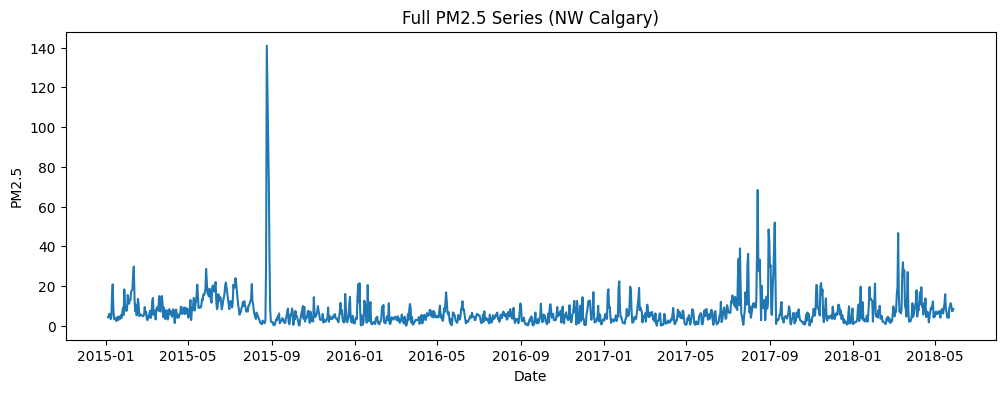

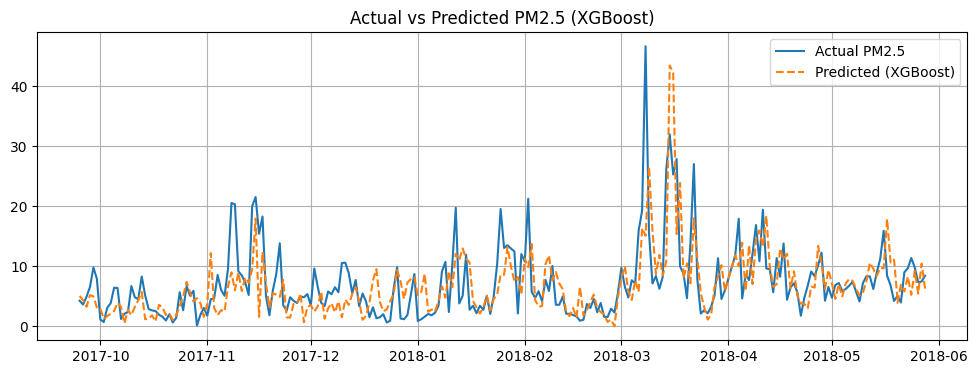

In [ ]:
#Plot of the full PM2.5 Time Series
plt.figure(figsize=(12,4))
plt.plot(df["date"], df["PM2.5"])
plt.title("Full PM2.5 Series (NW Calgary)")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.show()


#Plot of the Actual versus predicted AQI Values
plt.figure(figsize=(12,4))
plt.plot(df["date"].iloc[split:], y_test.values, label="Actual PM2.5")
plt.plot(df["date"].iloc[split:], preds, "--", label="Predicted (XGBoost)")
plt.legend()
plt.title("Actual vs Predicted PM2.5 (XGBoost)")
plt.grid(True)
plt.show()


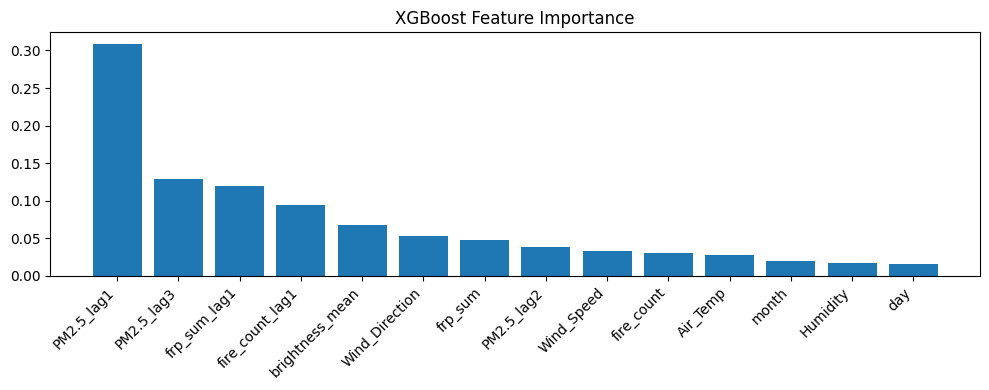

In [ ]:
importances = pd.DataFrame({
    "feature": x.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10,4))
plt.bar(importances["feature"], importances["importance"])
plt.xticks(rotation=45, ha="right")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

# **Predicting the PM2.5 Values using LSTM Model**

In [206]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers, models
from tensorflow.keras.layers import Dense, Dropout, LSTM
from sklearn.preprocessing import MinMaxScaler

In [210]:
#Sorts by date
df_lstm = df.sort_values("date").reset_index(drop=True)
pm_series = df_lstm["PM2.5"].values.reshape(-1, 1)

# Scales the PM2.5 between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
pm_scaled = scaler.fit_transform(pm_series)

window_size = 14 #Uses 14 days of past data to predict next day def create_sequences(data, window): x_seq, y_seq = [], [] for i in range(len(data) - window): x_seq.append(data[i:i+window, 0]) y_seq.append(data[i+window, 0]) return np.array(x_seq), np.array(y_seq)

def create_sequences(data, window):
  x_seq, y_seq = [], []
  for i in range(len(data) - window):
      x_seq.append(data[i:i+window, 0])
      y_seq.append(data[i+window, 0])
  return np.array(x_seq), np.array(y_seq)

x_seq, y_seq = create_sequences(pm_scaled, window_size)

#Reshapes the LSTM:(samples, timesteps, features)
x_seq = x_seq.reshape((x_seq.shape[0], x_seq.shape[1], 1))

print("x_seq shape:", x_seq.shape)
print("y_seq shape:", y_seq.shape)

x_seq shape: (1207, 14, 1)
y_seq shape: (1207,)


In [211]:
# Test the LSTM
split_lstm = int(len(x_seq) * 0.8)
x_train_seq, x_test_seq = x_seq[:split_lstm], x_seq[split_lstm:]
y_train_seq, y_test_seq = y_seq[:split_lstm], y_seq[split_lstm:]

print("Train sequences:", x_train_seq.shape[0])
print("Test sequences:", x_test_seq.shape[0])

Train sequences: 965
Test sequences: 242


In [212]:
#to prevent overfitting of the model
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [213]:
#Scales the PM2.5 between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))

scaler.fit(y_train_seq.reshape(-1, 1))
y_train_scaled = scaler.transform(y_train_seq.reshape(-1, 1))
y_test_scaled = scaler.transform(y_test_seq.reshape(-1, 1))


In [217]:
#training the model
tf.keras.backend.clear_session()

model_lstm = Sequential([
    layers.LSTM(128, return_sequences=True, input_shape=(window_size, 1)),
    layers.Dropout(0.2),

    layers.LSTM(128),
    layers.Dropout(0.2),

    layers.Dense(1)
])

model_lstm.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
)

history = model_lstm.fit(
    x_train_seq, y_train_scaled,
    validation_data=(x_test_seq, y_test_scaled),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0026 - val_loss: 0.0019
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0042 - val_loss: 0.0016
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0023 - val_loss: 0.0015
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0020 - val_loss: 0.0015
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0029 - val_loss: 0.0014
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0016 - val_loss: 0.0013
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0026 - val_loss: 0.0014
Epoch 11/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 12/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0015 - val_l

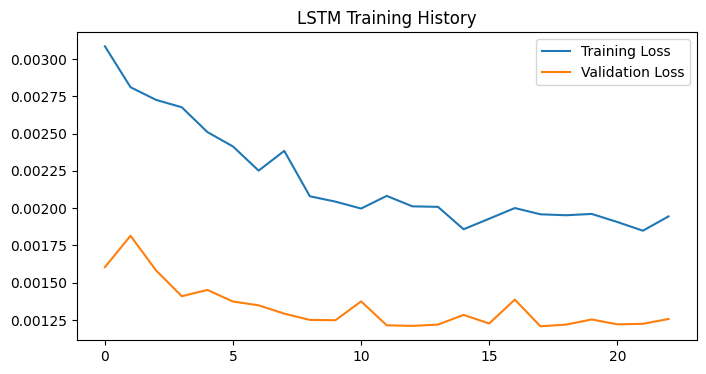

In [215]:
#plot of the training and validation loss
plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="Training Loss") #training loss
plt.plot(history.history["val_loss"], label="Validation Loss") #validation loss
plt.legend()
plt.title("LSTM Training History")
plt.show()


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
LSTM MAE: 0.024002851596203956
LSTM R² : 0.3287305202329497


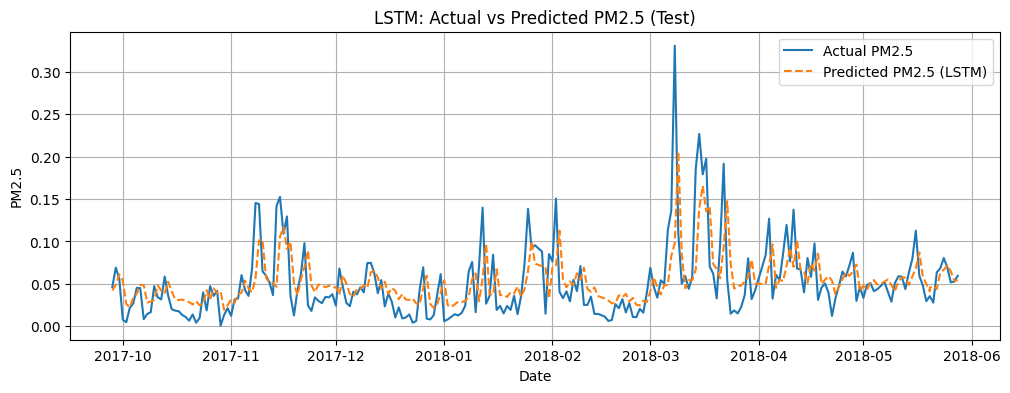

In [218]:
#Predict scaled values
y_pred_seq = model_lstm.predict(x_test_seq)
#Inverse scale to real PM2.5
y_test_inv = scaler.inverse_transform(y_test_seq.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred_seq)

print("LSTM MAE:", mean_absolute_error(y_test_inv, y_pred_inv))
print("LSTM R² :", r2_score(y_test_inv, y_pred_inv))
# Plot
test_dates = df_lstm["date"].iloc[-len(y_test_inv):]
plt.figure(figsize=(12,4))
plt.plot(test_dates, y_test_inv, label="Actual PM2.5")
plt.plot(test_dates, y_pred_inv, "--", label="Predicted PM2.5 (LSTM)")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.title("LSTM: Actual vs Predicted PM2.5 (Test)")
plt.legend()
plt.grid(True)
plt.show()

In [219]:
print("Using XGBoost Modelling")
print("MAE:", mean_absolute_error(y_test, preds),"ug/m3")
print("RSquared Score:", r2_score(y_test, preds), "\n")

print("Using LSTM Modelling")
print("LSTM MAE:", mean_absolute_error(y_test_inv, y_pred_inv),"ug/m3")
print("LSTM R² :", r2_score(y_test_inv, y_pred_inv))

Using XGBoost Modelling
MAE: 3.38266831943799 ug/m3
RSquared Score: 0.2944209366264271 

Using LSTM Modelling
LSTM MAE: 0.024002851596203956 ug/m3
LSTM R² : 0.3287305202329497


# **Future AQI Prediction/Forecasting**

**A. Using XGBoost model**

In [220]:
n_future = 7 # 7day forecast

# Start from the last known row
last_row = df.iloc[-1].copy()

future_dates = []
future_pm25 = []

# Get the feature columns used for training the XGBoost model
feature_columns = x.columns.tolist()

for i in range(n_future):
    features_series = last_row.drop(labels=["date", "PM2.5"])
    x_future_row = pd.DataFrame([features_series.values], columns=feature_columns).astype(float)

    next_pm25 = xgb_model.predict(x_future_row)[0]

    # Calculate the next date
    next_date = last_row["date"] + pd.Timedelta(days=1)

    future_dates.append(next_date)
    future_pm25.append(next_pm25)

    # Updated lag features for the next PM2.5 iteration
    last_row["PM2.5_lag3"] = last_row["PM2.5_lag2"]
    last_row["PM2.5_lag2"] = last_row["PM2.5_lag1"]
    last_row["PM2.5_lag1"] = next_pm25

    # Update wildfire lag features
    if "fire_count_lag1" in last_row.index:
        last_row["fire_count_lag1"] = last_row["fire_count"]
    if "frp_sum_lag1" in last_row.index:
        last_row["frp_sum_lag1"] = last_row["frp_sum"]


    if "fire_count" in last_row.index:
        last_row["fire_count"] = 0.0
    if "frp_sum" in last_row.index:
        last_row["frp_sum"] = 0.0
    if "brightness_mean" in last_row.index:
        last_row["brightness_mean"] = 0.0

    # Update date for the next iteration
    last_row["date"] = next_date
    last_row["month"] = next_date.month
    last_row["day"] = next_date.day


xgb_forecast_df = pd.DataFrame({
    "Date": future_dates,
    "PM2.5_forecast": future_pm25
})

print ("AQI values for a 7 day forecast are:", "\n", xgb_forecast_df)

AQI values for a 7 day forecast are: 
         Date  PM2.5_forecast
0 2018-05-29        6.206450
1 2018-05-30        6.585984
2 2018-05-31        6.607682
3 2018-06-01        6.360577
4 2018-06-02        7.243979
5 2018-06-03        7.433798
6 2018-06-04        7.761852


**B. Using LSTM Model**

In [221]:
n_future_1 = 7

last_window1 = pm_scaled[-window_size:].flatten()
future_scaled1 = []

current_window1 = last_window1.copy()

for i in range(n_future_1):
    inp = current_window1.reshape(1, window_size, 1)
    next_scaled1 = model_lstm.predict(inp)[0, 0]
    future_scaled1.append(next_scaled1)

    current_window1 = np.append(current_window1[1:], next_scaled1)


future_pm25_lstm = scaler.inverse_transform(
    np.array(future_scaled1).reshape(-1, 1)
).flatten()


last_date1 = df_lstm["date"].iloc[-1]
future_dates_lstm = [last_date1 + pd.Timedelta(days=i+1) for i in range(n_future_1)]

lstm_forecast_df = pd.DataFrame({
    "Date": future_dates_lstm,
    "PM2.5_forecast_LSTM": future_pm25_lstm
})

print("\n7 day Forecast using LSTM is:")
display(lstm_forecast_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

7 day Forecast using LSTM is:


,Date,PM2.5_forecast_LSTM
0,2018-05-29,0.058196
1,2018-05-30,0.057784
2,2018-05-31,0.057782
3,2018-06-01,0.058102
4,2018-06-02,0.058779
5,2018-06-03,0.059497
6,2018-06-04,0.060166


**Allows User to Input AQI Value and Determine the Level of Risk for Predicted AQI**





In [222]:
def aqhi_risk_alert(pm):
    if pm <= 10:
        return {
            "level": "Low",
            "message": "Air quality is good.",
            "risk": "No action required."
        }
    elif pm <= 20:
        return {
            "level": "Moderate",
            "message": "Air quality is moderate.",
            "risk": "Children, seniors, and persons with respiratory issues should limit outdoor activity."
        }
    elif pm <= 30:
        return {
            "level": "High",
            "message": "Health risk is high.",
            "risk": "Limited outdoor activities. Stay indoors if you have lung or heart conditions."
        }
    else:
        return {
            "level": "Very High",
            "message": "Health risk is dangerous.",
            "risk": "Avoid outdoor activity entirely."
        }



In [223]:
notifications = []

min_len = min(len(preds), len(future_pm25_lstm))

for i in range (min_len):
  avg_pm = (preds[i] + future_pm25_lstm[i]) / 2
  message = aqhi_risk_alert(avg_pm)

  notifications.append({
    "Day": xgb_forecast_df["Date"].iloc[i],
    "PM2.5": round(avg_pm, 2),
    "Level": message["level"],
    "Message": message["message"],
    "Risk": message["risk"]
  })
notifications_df = pd.DataFrame(notifications)
display(notifications_df)

,Day,PM2.5,Level,Message,Risk
0,2018-05-29,2.54,Low,Air quality is good.,No action required.
1,2018-05-30,2.17,Low,Air quality is good.,No action required.
2,2018-05-31,1.63,Low,Air quality is good.,No action required.
3,2018-06-01,2.60,Low,Air quality is good.,No action required.
4,2018-06-02,2.50,Low,Air quality is good.,No action required.
5,2018-06-03,1.58,Low,Air quality is good.,No action required.
6,2018-06-04,1.48,Low,Air quality is good.,No action required.


In [ ]:
pm_value_str = input("Enter the PM2.5 value: ")

try:
  pm_value = float(pm_value_str)
except:
  print("Invalid input. Please enter a valid value.")
else:
  message = aqhi_risk_alert(pm_value)
  print(f"Level of Risk: {message['level']}")
  print(f"Message: {message['message']}")
  print(f"Risk: {message['risk']}")